# A alise Exploratoria Detalhada - AcTBeCalf

Este notebook realiza uma EDA detalhada do arquivo `dataset/AcTBeCalf.csv`, cobrindo:
- estrutura e tipos de dados
- qualidade do dataset (faltantes, duplicatas, consistencia)
- distribuicao temporal e por classes
- estatisticas dos eixos acelerometricos
- analise por segmentos (`segId`) e individuos (`calfId`)
- correlacoes, outliers e feature derivada de magnitude

In [1]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 160)

DATA_PATH = Path('../dataset/AcTBeCalf.csv')
DATA_PATH.exists(), DATA_PATH

(True, PosixPath('../dataset/AcTBeCalf.csv'))

In [2]:
# Carregamento com dtypes otimizados para reduzir memoria
dtype_map = {
    'calfId': 'int32',
    'accX': 'float32',
    'accY': 'float32',
    'accZ': 'float32',
    'behaviour': 'category',
    'segId': 'int32',
}

df = pd.read_csv(
    DATA_PATH,
    parse_dates=['dateTime'],
    dtype=dtype_map
)

print(f'Linhas: {len(df):,}'.replace(',', '.'))
print(f'Colunas: {df.shape[1]}')
df.head()

Linhas: 2.467.162
Colunas: 7


,dateTime,calfId,accX,accY,accZ,behaviour,segId
0,2022-02-24 00:08:34.402385,1306,0.812500,0.390625,0.281250,oral_manipulation_of_pen,0
1,2022-02-24 00:08:34.441385,1306,0.687500,0.375000,0.375000,oral_manipulation_of_pen,0
2,2022-02-24 00:08:34.481386,1306,0.625000,0.296875,0.265625,oral_manipulation_of_pen,0
3,2022-02-24 00:08:34.521386,1306,0.703125,0.218750,0.218750,oral_manipulation_of_pen,0
4,2022-02-24 00:08:34.560387,1306,0.734375,0.218750,0.250000,oral_manipulation_of_pen,0


In [3]:
# Estrutura geral e uso de memoria
display(df.info())
mem_mb = df.memory_usage(deep=True).sum() / 1024**2
print(f'Consumo aproximado de memoria: {mem_mb:,.2f} MB'.replace(',', '.'))

display(df.describe(include='all').T)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2467162 entries, 0 to 2467161
Data columns (total 7 columns):
 #   Column     Dtype         
---  ------     -----         
 0   dateTime   datetime64[ns]
 1   calfId     int32         
 2   accX       float32       
 3   accY       float32       
 4   accZ       float32       
 5   behaviour  category      
 6   segId      int32         
dtypes: category(1), datetime64[ns](1), float32(3), int32(2)
memory usage: 68.2 MB


None

Consumo aproximado de memoria: 68.24 MB


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
dateTime,2467162,NaN,NaN,NaN,2022-02-21 15:04:17.709991168,2022-02-04 19:16:40.561094,2022-02-11 14:30:10.600713728,2022-02-22 10:01:27.126682880,2022-02-25 05:23:58.899858944,2022-03-31 18:01:08.874621,NaN
calfId,2467162.0,NaN,NaN,NaN,1363.367528,1302.0,1312.0,1343.0,1408.0,1455.0,55.239442
accX,2467162.0,NaN,NaN,NaN,0.703701,-5.65625,0.625,0.796875,0.90625,7.859375,0.432487
accY,2467162.0,NaN,NaN,NaN,-0.138377,-7.765625,-0.421875,-0.15625,0.140625,6.59375,0.367015
accZ,2467162.0,NaN,NaN,NaN,0.025851,-3.625,-0.171875,0.0,0.296875,6.59375,0.403167
behaviour,2467162,50,lying,965184,NaN,NaN,NaN,NaN,NaN,NaN,NaN
segId,2467162.0,NaN,NaN,NaN,1860.286609,0.0,865.0,1836.0,2919.0,4015.0,1176.876765


In [4]:
# Qualidade de dados: faltantes, duplicatas e cardinalidade
missing = df.isna().sum().to_frame('missing_count')
missing['missing_pct'] = (missing['missing_count'] / len(df) * 100).round(4)
display(missing)

dup_rows = df.duplicated().sum()
print(f'Linhas duplicadas exatas: {dup_rows:,}'.replace(',', '.'))

card = pd.Series({c: df[c].nunique(dropna=False) for c in df.columns}, name='nunique').to_frame()
display(card)

,missing_count,missing_pct
dateTime,0,0.0
calfId,0,0.0
accX,0,0.0
accY,0,0.0
accZ,0,0.0
behaviour,0,0.0
segId,0,0.0


Linhas duplicadas exatas: 0


,nunique
dateTime,2466806
calfId,30
accX,580
accY,514
accZ,467
behaviour,50
segId,4016


In [5]:
# Cobertura temporal
tmin, tmax = df['dateTime'].min(), df['dateTime'].max()
print('Inicio:', tmin)
print('Fim   :', tmax)
print('Duracao total:', tmax - tmin)

coverage_by_calf = (
    df.groupby('calfId')['dateTime']
      .agg(['min', 'max', 'count'])
      .rename(columns={'count': 'n_amostras'})
)
coverage_by_calf['duracao'] = coverage_by_calf['max'] - coverage_by_calf['min']
display(coverage_by_calf.sort_values('n_amostras', ascending=False).head(20))

Inicio: 2022-02-04 19:16:40.561094
Fim   : 2022-03-31 18:01:08.874621
Duracao total: 54 days 22:44:28.313527


,min,max,n_amostras,duracao
calfId,,,,
1455,2022-02-21 22:53:47.790634,2022-02-25 10:51:44.350562,168396,3 days 11:57:56.559928
1403,2022-02-25 01:59:41.265955,2022-02-25 06:47:19.024292,163844,0 days 04:47:37.758337
1308,2022-02-04 22:25:22.549966,2022-02-26 22:48:08.993139,157910,22 days 00:22:46.443173
1302,2022-02-21 16:59:47.377211,2022-02-24 12:54:41.016582,137165,2 days 19:54:53.639371
1303,2022-02-10 03:57:37.664074,2022-02-27 01:25:45.634775,137150,16 days 21:28:07.970701
1314,2022-02-07 07:30:16.032338,2022-02-22 10:19:48.141019,135178,15 days 02:49:32.108681
1405,2022-02-11 12:36:08.815859,2022-02-27 01:33:22.376736,113070,15 days 12:57:13.560877
1320,2022-02-05 04:25:22.922768,2022-02-27 14:24:36.122163,110603,22 days 09:59:13.199395
1306,2022-02-06 17:30:17.019699,2022-02-24 00:31:23.286498,107829,17 days 07:01:06.266799


In [6]:
# Estimativa de frequencia amostral por animal (delta temporal)
ordered = df[['calfId', 'dateTime']].sort_values(['calfId', 'dateTime'])
delta_s = ordered.groupby('calfId')['dateTime'].diff().dt.total_seconds()
delta_s = delta_s[(delta_s.notna()) & (delta_s > 0)]

print('Resumo global de delta (segundos):')
display(delta_s.describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).to_frame('delta_s'))

freq_hz_est = 1.0 / delta_s.median() if len(delta_s) else np.nan
print(f'Frequencia aproximada (1/mediana_delta): {freq_hz_est:.2f} Hz')

Resumo global de delta (segundos):


,delta_s
count,2.466782e+06
mean,1.233333e+01
std,4.404676e+03
min,3.700000e-02
1%,3.800000e-02
5%,3.800100e-02
50%,4.000100e-02
95%,4.200100e-02
99%,4.200200e-02
max,3.185953e+06


Frequencia aproximada (1/mediana_delta): 25.00 Hz


,count,pct
behaviour,,
lying,965184,39.121
drinking_milk,217075,8.799
standing,188908,7.657
eating_concentrates,146067,5.920
sniff,134768,5.462
eating_bedding,129119,5.234
oral_manipulation_of_pen,118210,4.791
grooming,114181,4.628
running,83345,3.378


Razao entre classe majoritaria e minoritaria: 11915.85x


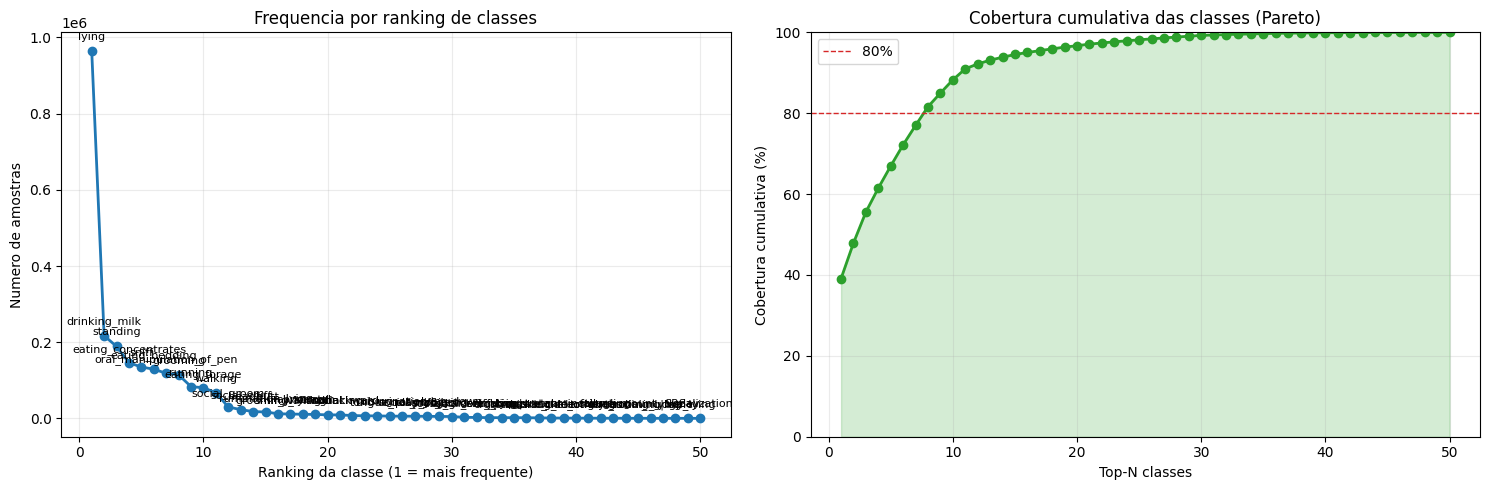

In [7]:
# Balanceamento de classes de comportamento (visual analitico sem barras)
beh_counts = df['behaviour'].value_counts(dropna=False).to_frame('count')
beh_counts['pct'] = (beh_counts['count'] / len(df) * 100).round(3)
beh_counts = beh_counts.sort_values('count', ascending=False)
display(beh_counts)

imbalance_ratio = beh_counts['count'].max() / beh_counts['count'].min()
print(f'Razao entre classe majoritaria e minoritaria: {imbalance_ratio:.2f}x')

# Visualizacao melhor: curva de frequencia por ranking + cumulativa (Pareto)
try:
    import matplotlib.pyplot as plt

    x = np.arange(1, len(beh_counts) + 1)
    y = beh_counts['count'].values
    y_pct = beh_counts['pct'].values
    cum_pct = np.cumsum(y_pct)

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    axes[0].plot(x, y, marker='o', linewidth=2)
    axes[0].set_title('Frequencia por ranking de classes')
    axes[0].set_xlabel('Ranking da classe (1 = mais frequente)')
    axes[0].set_ylabel('Numero de amostras')
    axes[0].grid(alpha=0.25)

    for i, (label, value) in enumerate(zip(beh_counts.index.astype(str), y), start=1):
        axes[0].annotate(label, (i, value), textcoords='offset points', xytext=(0, 8), ha='center', fontsize=8)

    axes[1].plot(x, cum_pct, marker='o', linewidth=2, color='tab:green')
    axes[1].fill_between(x, cum_pct, alpha=0.2, color='tab:green')
    axes[1].axhline(80, linestyle='--', linewidth=1, color='tab:red', label='80%')
    axes[1].set_title('Cobertura cumulativa das classes (Pareto)')
    axes[1].set_xlabel('Top-N classes')
    axes[1].set_ylabel('Cobertura cumulativa (%)')
    axes[1].set_ylim(0, 100)
    axes[1].grid(alpha=0.25)
    axes[1].legend()

    plt.tight_layout()
    plt.show()
except Exception as e:
    print('Nao foi possivel gerar as curvas de balanceamento:', e)

In [16]:
# Distribuicao de classes por animal
ct = pd.crosstab(df['calfId'], df['behaviour'])
ct_pct = ct.div(ct.sum(axis=1), axis=0).mul(100).round(2)

print('Contagens por calfId x behaviour:')
display(ct)

Contagens por calfId x behaviour:


behaviour,backward,drinking,drinking_electrolytes,drinking_milk,eating,eating_bedding,eating_concentrates,eating_forage,grooming,grooming|None,headbutt,lying,lying-down,oral_manipulation_of_pen,rub,running,scratch,sniff,sniff_walking,social_groom,social_sniff,standing,walking,defecation,urination,rising,social_nudge,stretch,tongue_rolling,grooming_lying,sniff_lying,social_sniff_lying,mount,social_groom_lying,SRS,fall,play_object,drinking|water,social_nudge_lying,vocalization,cross-suckle_other,cross-suckle_udder,jump,social,rumination_lying,abnormal,cough,rumination,play,tongue_rolling_lying
calfId,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1302,209,763,0,2214,0,14518,4262,4856,6234,0,0,71025,52,6434,0,5520,288,6556,0,2922,451,7291,2419,444,327,78,302,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1303,0,0,0,12641,0,14699,3761,29925,1446,0,0,40869,213,1621,0,1998,220,8487,452,710,526,12812,2194,0,0,234,436,0,1888,396,0,1593,0,0,0,29,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1306,76,3485,0,1826,0,11540,2750,3013,4218,0,2530,30280,503,11753,0,4343,538,14514,741,3406,503,8081,1697,0,477,243,0,63,251,0,0,0,0,0,0,0,972,0,0,0,0,0,0,0,0,0,26,0,0,0
1308,321,0,0,10998,395,5474,0,2683,6115,0,2635,68946,223,7577,0,7989,280,11967,0,432,378,13967,3782,0,0,292,556,178,0,0,0,0,0,0,0,0,516,0,0,0,864,1673,215,9152,0,0,205,0,97,0
1312,0,0,0,1567,0,28343,12529,3534,5198,0,1151,7382,193,18858,0,3515,521,6227,1037,224,1537,5295,516,414,311,172,91,0,190,0,0,0,0,0,171,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1314,480,4845,0,34087,0,6421,12175,2303,11425,0,2814,33495,157,469,1542,3307,2964,2445,0,871,941,6845,4694,0,836,304,836,177,0,0,0,0,0,0,0,0,559,0,0,0,0,0,0,33,0,0,0,153,0,0
1319,122,0,0,1611,0,22398,1946,1925,1409,0,671,38666,394,4733,451,3282,924,6424,82,3196,162,4938,1113,0,0,285,0,0,366,0,0,0,0,0,0,0,2144,0,0,0,0,0,155,0,0,0,0,0,0,0
1320,479,0,0,13126,0,2306,21008,3873,7269,0,0,8586,295,14039,0,4134,304,9299,614,0,1800,11341,3619,0,0,135,0,0,600,1819,1936,0,115,1170,0,0,0,0,0,0,0,0,783,0,1646,0,0,0,0,307
1328,0,0,0,480,0,0,3862,0,400,0,0,26424,0,135,0,1594,0,2819,56,5804,0,8276,159,0,0,56,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,49,0,0,0,0,0,0,0


In [24]:
# Cobertura de comportamentos por vaca (tabela + listas)
cow_behavior = df[['calfId', 'behaviour']].drop_duplicates()
n_cows_by_behavior = (
    cow_behavior.groupby('behaviour')['calfId']
    .nunique()
    .sort_values(ascending=False)
    .to_frame('n_vacas')
)

total_cows = df['calfId'].nunique()
n_cows_by_behavior['pct_vacas'] = (n_cows_by_behavior['n_vacas'] / total_cows * 100).round(2)

print(f'Total de vacas no dataset: {total_cows}')
print('Tabela: numero de vacas que apresentam cada comportamento (ordem decrescente)')
display(n_cows_by_behavior)

# Comportamentos presentes em todas as vacas
beh_all_cows = n_cows_by_behavior[n_cows_by_behavior['n_vacas'] == total_cows].index.tolist()
print('\nComportamentos que TODAS as vacas possuem:')
if beh_all_cows:
    for b in beh_all_cows:
        print(f'- {b}')
else:
    print('- Nenhum comportamento presente em todas as vacas.')

# Comportamentos presentes em pelo menos 25 vacas
threshold = 25
beh_at_least_25 = n_cows_by_behavior[n_cows_by_behavior['n_vacas'] >= threshold].index.tolist()
print(f'\nComportamentos presentes em pelo menos {threshold} vacas:')
if beh_at_least_25:
    for b in beh_at_least_25:
        print(f'- {b}')
else:
    print(f'- Nenhum comportamento atingiu {threshold} vacas.')

n_cows_by_behavior.index

Total de vacas no dataset: 30
Tabela: numero de vacas que apresentam cada comportamento (ordem decrescente)


,n_vacas,pct_vacas
behaviour,,
walking,30,100.00
standing,30,100.00
sniff,29,96.67
grooming,29,96.67
lying,27,90.00
drinking_milk,27,90.00
social_sniff,25,83.33
rising,25,83.33
running,25,83.33



Comportamentos que TODAS as vacas possuem:
- walking
- standing

Comportamentos presentes em pelo menos 25 vacas:
- walking
- standing
- sniff
- grooming
- lying
- drinking_milk
- social_sniff
- rising
- running


CategoricalIndex(['walking', 'standing', 'sniff', 'grooming', 'lying', 'drinking_milk', 'social_sniff', 'rising', 'running', 'oral_manipulation_of_pen',
                  'lying-down', 'eating_concentrates', 'scratch', 'sniff_walking', 'backward', 'eating_bedding', 'eating_forage', 'social_groom',
                  'social_nudge', 'headbutt', 'rub', 'urination', 'tongue_rolling', 'stretch', 'jump', 'grooming_lying', 'play_object', 'rumination_lying',
                  'sniff_lying', 'defecation', 'fall', 'cough', 'drinking_electrolytes', 'drinking', 'social_sniff_lying', 'social_groom_lying', 'mount',
                  'social', 'drinking|water', 'rumination', 'eating', 'grooming|None', 'cross-suckle_udder', 'cross-suckle_other', 'vocalization',
                  'social_nudge_lying', 'SRS', 'abnormal', 'play', 'tongue_rolling_lying'],
                 categories=['backward', 'drinking', 'drinking_electrolytes', 'drinking_milk', ..., 'cough', 'rumination', 'play', 'tongue_rolling_lying

In [9]:
# Estatisticas dos sinais de aceleracao
acc_cols = ['accX', 'accY', 'accZ']
desc_acc = df[acc_cols].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T
display(desc_acc)

corr = df[acc_cols].corr()
print('Correlacao entre eixos:')
display(corr)

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
accX,2467162.0,0.703701,0.432487,-5.656250,-0.937500,-0.515625,0.625000,0.796875,0.906250,1.015625,1.390625,7.859375
accY,2467162.0,-0.138377,0.367015,-7.765625,-0.859375,-0.671875,-0.421875,-0.156250,0.140625,0.453125,0.640625,6.593750
accZ,2467162.0,0.025851,0.403167,-3.625000,-0.875000,-0.734375,-0.171875,0.000000,0.296875,0.687500,0.781250,6.593750


Correlacao entre eixos:


,accX,accY,accZ
accX,1.000000,-0.175291,-0.090452
accY,-0.175291,1.000000,0.009631
accZ,-0.090452,0.009631,1.000000


In [10]:
# Feature derivada: magnitude vetorial da aceleracao
df['acc_mag'] = np.sqrt(df['accX']**2 + df['accY']**2 + df['accZ']**2).astype('float32')
display(df['acc_mag'].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).to_frame('acc_mag'))

mag_by_beh = df.groupby('behaviour')['acc_mag'].agg(['mean', 'std', 'median', 'min', 'max']).sort_values('mean', ascending=False)
display(mag_by_beh)

,acc_mag
count,2.467162e+06
mean,9.803233e-01
std,1.956183e-01
min,1.562500e-02
1%,6.470712e-01
5%,8.415771e-01
50%,9.690020e-01
95%,1.081403e+00
99%,1.653668e+00
max,1.024298e+01


,mean,std,median,min,max
behaviour,,,,,
running,1.324114,0.884829,1.081065,0.022097,10.242983
jump,1.259375,0.838630,0.994492,0.034939,6.572351
fall,1.121748,0.658819,0.976281,0.123031,7.885750
mount,1.083514,0.513051,1.014362,0.084143,3.946573
tongue_rolling_lying,1.060330,0.017481,1.059163,1.017546,1.124240
grooming_lying,1.010443,0.070797,1.010323,0.638334,1.603600
social_groom_lying,1.001950,0.049328,1.005296,0.654201,1.210106
sniff_lying,1.000924,0.043462,0.999756,0.835755,1.267360
eating,0.999985,0.135625,0.996454,0.454201,1.675740


In [11]:
# Outliers por IQR nos eixos
outlier_summary = []
for col in ['accX', 'accY', 'accZ', 'acc_mag']:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = ((df[col] < low) | (df[col] > high)).sum()
    outlier_summary.append({
        'feature': col,
        'q1': q1,
        'q3': q3,
        'iqr': iqr,
        'low_bound': low,
        'high_bound': high,
        'outliers': int(n_out),
        'outlier_pct': float(n_out / len(df) * 100),
    })

outlier_df = pd.DataFrame(outlier_summary).sort_values('outlier_pct', ascending=False)
display(outlier_df)

,feature,q1,q3,iqr,low_bound,high_bound,outliers,outlier_pct
0,accX,0.625000,0.906250,0.281250,0.203125,1.328125,193242,7.832562
3,acc_mag,0.926366,1.015144,0.088778,0.793199,1.148311,135300,5.484034
2,accZ,-0.171875,0.296875,0.468750,-0.875000,1.000000,29875,1.210905
1,accY,-0.421875,0.140625,0.562500,-1.265625,0.984375,5848,0.237033


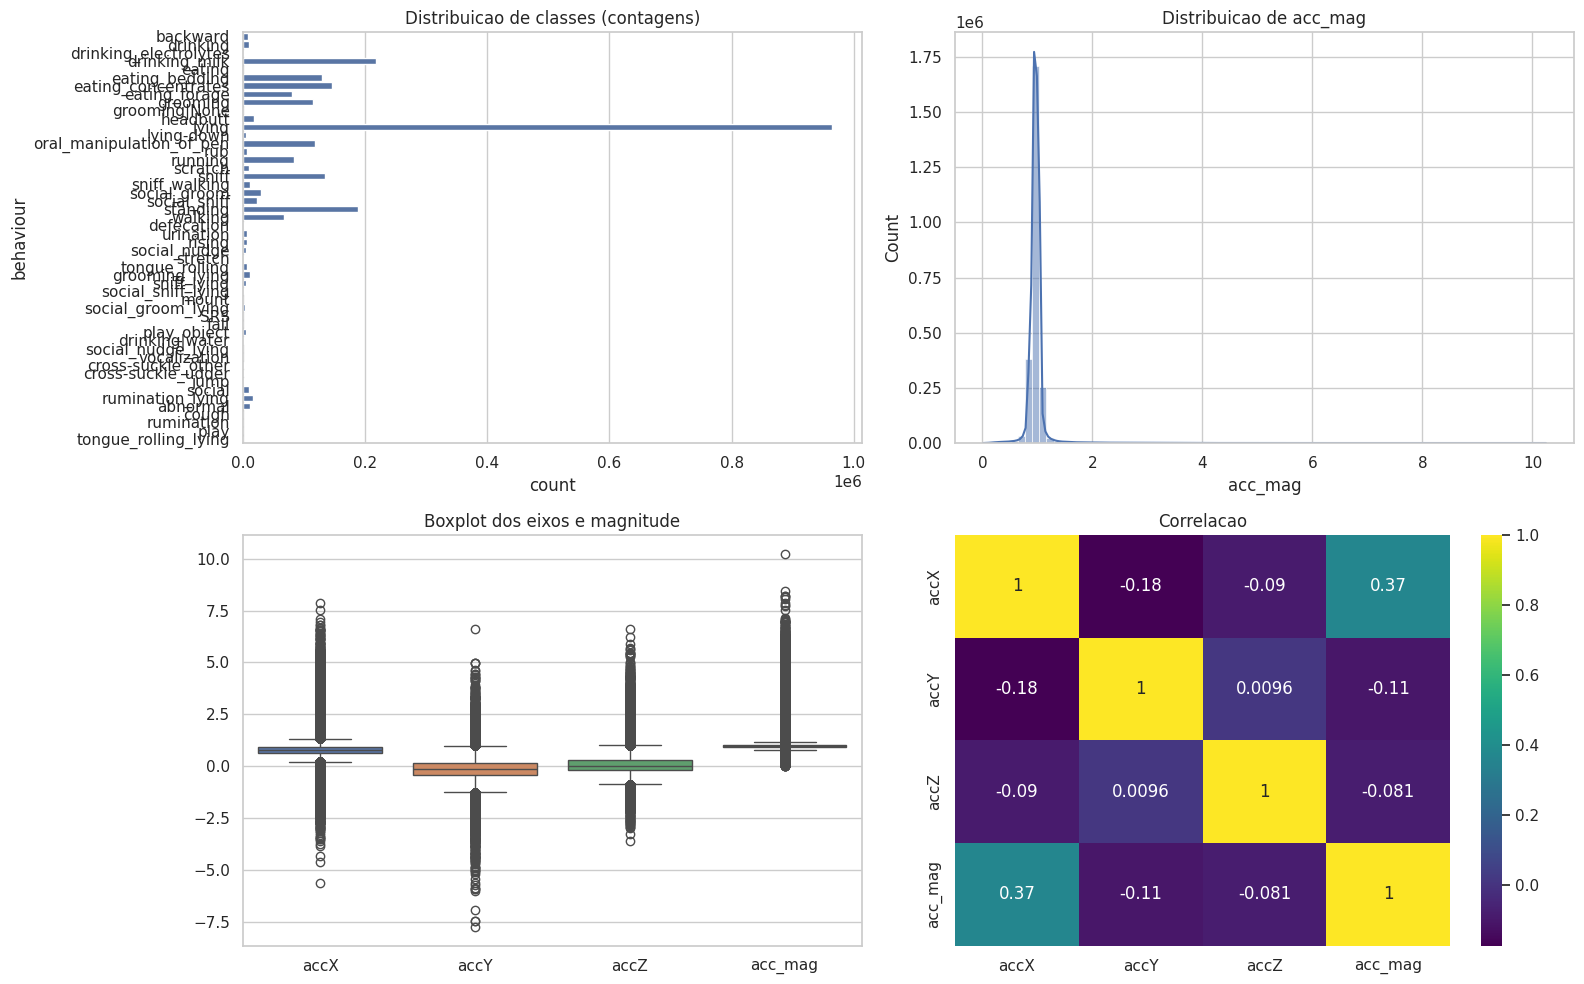

In [18]:
# Visualizacoes (opcional): so executa se matplotlib/seaborn estiverem disponiveis
HAS_PLOT = True
try:
    import matplotlib.pyplot as plt
    import seaborn as sns
    sns.set_theme(style='whitegrid')
except Exception as e:
    HAS_PLOT = False
    print('Bibliotecas de plot nao disponiveis:', e)

if HAS_PLOT:
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))

    beh_counts_plot = df['behaviour'].value_counts()
    sns.barplot(x=beh_counts_plot.values, y=beh_counts_plot.index, ax=axes[0, 0])
    axes[0, 0].set_title('Distribuicao de classes (contagens)')
    axes[0, 0].set_xlabel('count')

    sns.histplot(df['acc_mag'], bins=80, kde=True, ax=axes[0, 1])
    axes[0, 1].set_title('Distribuicao de acc_mag')

    sns.boxplot(data=df[['accX', 'accY', 'accZ', 'acc_mag']], ax=axes[1, 0])
    axes[1, 0].set_title('Boxplot dos eixos e magnitude')

    sns.heatmap(df[['accX', 'accY', 'accZ', 'acc_mag']].corr(), annot=True, cmap='viridis', ax=axes[1, 1])
    axes[1, 1].set_title('Correlacao')

    plt.tight_layout()
    plt.show()

Comportamentos plotados: 47
Amostras por trecho de 5s: 125 (dt mediano ~ 0.0400s)


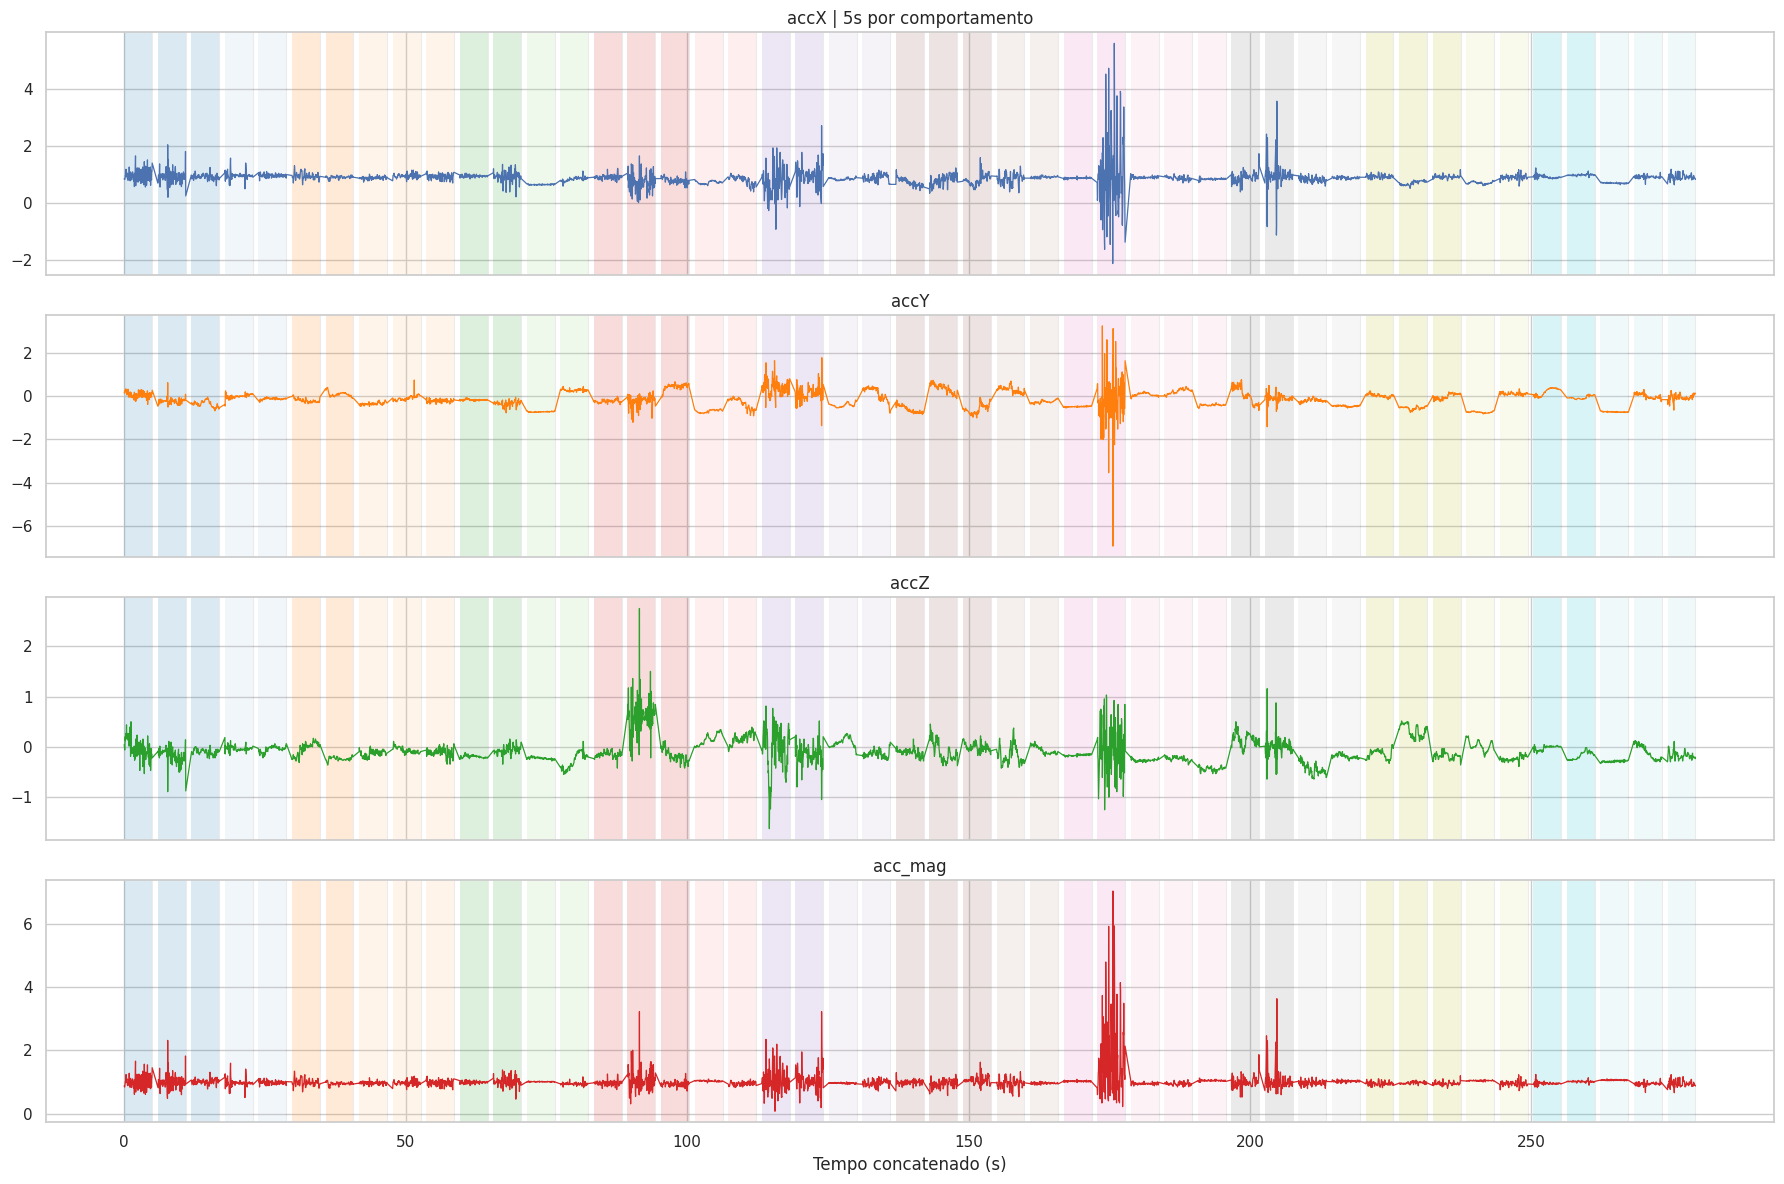

In [23]:
# Janela de 5 segundos de cada comportamento, com fundo colorido por label
if HAS_PLOT:
    from matplotlib.patches import Patch

    work = df[['dateTime', 'calfId', 'accX', 'accY', 'accZ', 'acc_mag', 'behaviour']].copy()
    work = work.sort_values(['calfId', 'dateTime'])
    work['behaviour'] = work['behaviour'].astype(str)

    # Estima taxa de amostragem global para converter 5s em numero de amostras
    dt = work.groupby('calfId')['dateTime'].diff().dt.total_seconds()
    dt = dt[(dt.notna()) & (dt > 0)]
    median_dt = float(dt.median()) if len(dt) else 0.04
    samples_5s = max(10, int(round(5.0 / median_dt)))

    # Procura, para cada comportamento, um trecho contiguo com pelo menos 5s
    max_gap = median_dt * 2.5 if median_dt > 0 else 0.2
    behavior_segments = []

    for beh in sorted(work['behaviour'].dropna().unique()):
        beh_df = work[work['behaviour'] == beh].sort_values(['calfId', 'dateTime'])
        found = None

        for calf_id, g in beh_df.groupby('calfId', sort=False):
            g = g.sort_values('dateTime').copy()
            gap = g['dateTime'].diff().dt.total_seconds().fillna(0)
            # novo bloco quando muda muito o tempo
            block_id = (gap > max_gap).cumsum()

            for _, block in g.groupby(block_id):
                if len(block) >= samples_5s:
                    found = block.iloc[:samples_5s].copy()
                    found['behaviour'] = beh
                    found['calfId'] = calf_id
                    break
            if found is not None:
                break

        if found is not None:
            behavior_segments.append(found)

    if not behavior_segments:
        print('Nao foi possivel montar segmentos de 5s por comportamento.')
    else:
        # Concatena segmentos em um eixo temporal artificial para comparar lado a lado
        labels_present = [seg['behaviour'].iloc[0] for seg in behavior_segments]
        cmap = plt.get_cmap('tab20', max(1, len(labels_present)))
        label_to_color = {label: cmap(i) for i, label in enumerate(labels_present)}

        gap_seconds = 1.0
        concat_t, concat_x, concat_y, concat_z, concat_m = [], [], [], [], []
        spans = []
        cur_t = 0.0

        for seg in behavior_segments:
            beh = seg['behaviour'].iloc[0]
            calf_id = seg['calfId'].iloc[0]
            n = len(seg)
            local_t = np.arange(n) * median_dt
            t_values = cur_t + local_t

            concat_t.extend(t_values.tolist())
            concat_x.extend(seg['accX'].to_numpy().tolist())
            concat_y.extend(seg['accY'].to_numpy().tolist())
            concat_z.extend(seg['accZ'].to_numpy().tolist())
            concat_m.extend(seg['acc_mag'].to_numpy().tolist())

            t0 = float(t_values[0])
            t1 = float(t_values[-1]) if len(t_values) > 1 else float(t_values[0] + median_dt)
            spans.append((t0, t1, beh, calf_id))

            cur_t = t1 + gap_seconds

        fig, axes = plt.subplots(4, 1, figsize=(18, 12), sharex=True)

        for ax in axes:
            for t0, t1, beh, _ in spans:
                ax.axvspan(t0, t1, color=label_to_color.get(beh, 'lightgray'), alpha=0.16, linewidth=0)
            for t0, t1, _, _ in spans:
                ax.axvline(t1, color='black', alpha=0.08, linewidth=0.8)

        axes[0].plot(concat_t, concat_x, linewidth=0.9)
        axes[0].set_title('accX | 5s por comportamento')

        axes[1].plot(concat_t, concat_y, linewidth=0.9, color='tab:orange')
        axes[1].set_title('accY')

        axes[2].plot(concat_t, concat_z, linewidth=0.9, color='tab:green')
        axes[2].set_title('accZ')

        axes[3].plot(concat_t, concat_m, linewidth=0.9, color='tab:red')
        axes[3].set_title('acc_mag')
        axes[3].set_xlabel('Tempo concatenado (s)')

        # legend_items = [
        #     Patch(facecolor=label_to_color[b], edgecolor='none', alpha=0.35, label=b)
        #     for b in labels_present
        # ]
        # axes[0].legend(handles=legend_items, title='behaviour (5s cada)', loc='upper right', ncol=2, fontsize=8)

        print(f'Comportamentos plotados: {len(labels_present)}')
        print(f'Amostras por trecho de 5s: {samples_5s} (dt mediano ~ {median_dt:.4f}s)')

        plt.tight_layout()
        plt.show()
else:
    print('Pule esta celula ou instale matplotlib/seaborn para gerar os graficos.')

## Checklist de conclusoes para modelagem

Use os resultados acima para responder:
1. Existe desbalanceamento severo entre classes de `behaviour`?
2. A frequencia amostral e regular para todos os `calfId`?
3. Quais eixos carregam mais variabilidade e outliers?
4. Segmentos (`segId`) tendem a ser puros em termos de classe?
5. A magnitude `acc_mag` melhora separabilidade entre comportamentos?

Com base nisso, voce pode definir:
- estrategia de normalizacao
- tecnica de balanceamento
- janelamento e stride
- conjunto inicial de features para baseline